In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
df = pd.read_csv('/Users/purna/Desktop/EE 501/C1/Question1/iris/iris.data', header=None)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
label_map = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

y = np.array([label_map[name] for name in y])
X_train = np.vstack([X[0:35],   X[50:85],   X[100:135]])
X_test  = np.vstack([X[35:50],  X[85:100],  X[135:150]])
y_train = np.hstack([y[0:35],   y[50:85],   y[100:135]])
y_test  = np.hstack([y[35:50],  y[85:100],  y[135:150]])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

def one_hot_tanh(y, num_classes=3):
    result = np.full((len(y), num_classes), -1)
    for i, label in enumerate(y):
        result[i, label] = 1
    return result

def one_hot_softmax(y, num_classes=3):
    result = np.zeros((len(y), num_classes))
    for i, label in enumerate(y):
        result[i, label] = 1
    return result

Y_train_tanh = one_hot_tanh(y_train)
Y_test_tanh  = one_hot_tanh(y_test)

Y_train_soft = one_hot_softmax(y_train)
Y_test_soft  = one_hot_softmax(y_test)

W = np.random.randn(4, 3) * 0.01
b = np.zeros((1, 3))

In [12]:
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return e_z / e_z.sum(axis=-1, keepdims=True)

def forward(X, W, b, activation='tanh'):
    z = X @ W + b
    if activation == 'tanh':
        return tanh(z)
    elif activation == 'softmax':
        return softmax(z)

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-9, 1)
    return -np.sum(y_true * np.log(y_pred))

def backward_tanh(X, y_pred, y_true, W, b, lr):
    error  = y_pred - y_true
    delta  = error * tanh_derivative(X @ W + b)
    dW     = X.T @ delta
    db     = delta
    W = W - lr * dW
    b = b - lr * db
    return W, b

def backward_softmax(X, y_pred, y_true, W, b, lr):
    delta  = y_pred - y_true
    dW     = X.T @ delta
    db     = delta
    W = W - lr * dW
    b = b - lr * db
    return W, b

In [13]:

def predict(X, W, b, activation='tanh'):
    z = np.dot(X, W) + b
    if activation == 'tanh':
        return np.argmax(np.tanh(z), axis=1)
    elif activation == 'softmax':
        e_z = np.exp(z - z.max(axis=1, keepdims=True))
        return np.argmax(e_z / e_z.sum(axis=1, keepdims=True), axis=1)
    else:
        raise ValueError("Unsupported activation function")

In [14]:
lr     = 0.01
epochs = 200

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(X_train)):
        X_i = X_train[i:i+1]

        Y_i = Y_train_tanh[i:i+1]

        y_pred = forward(X_i, W, b, activation='tanh')
        loss   = mse_loss(y_pred, Y_i)
        total_loss += loss

        W, b = backward_tanh(X_i, y_pred, Y_i, W, b, lr)

    avg_loss = total_loss / len(X_train)
    train_losses.append(avg_loss)
    y_hat = predict(X_test, W, b, activation='tanh')
    accuracy = np.mean(y_hat == y_test) * 100
    test_accuracies.append(accuracy)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}  |  Loss: {avg_loss:.4f}  |  Test Acc: {accuracy:.1f}%")

Epoch 0  |  Loss: 0.5462  |  Test Acc: 77.8%
Epoch 20  |  Loss: 0.2893  |  Test Acc: 91.1%
Epoch 40  |  Loss: 0.2751  |  Test Acc: 93.3%
Epoch 60  |  Loss: 0.2691  |  Test Acc: 95.6%
Epoch 80  |  Loss: 0.2656  |  Test Acc: 95.6%
Epoch 100  |  Loss: 0.2633  |  Test Acc: 95.6%
Epoch 120  |  Loss: 0.2616  |  Test Acc: 95.6%
Epoch 140  |  Loss: 0.2603  |  Test Acc: 95.6%
Epoch 160  |  Loss: 0.2592  |  Test Acc: 95.6%
Epoch 180  |  Loss: 0.2584  |  Test Acc: 95.6%


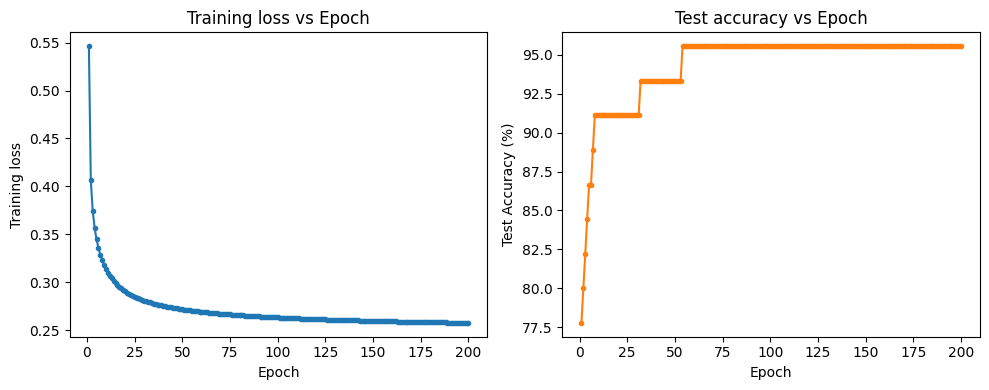

In [15]:

epochs_range = np.arange(1, epochs+1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Training loss vs Epoch')

plt.subplot(1,2,2)
plt.plot(epochs_range, test_accuracies, marker='o', color='tab:orange', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test accuracy vs Epoch')

plt.tight_layout()
plt.savefig('training_loss_accuracy.png', dpi=150)
plt.show()

In [16]:
y_hat    = predict(X_test, W, b, activation='tanh')
accuracy = np.mean(y_hat == y_test) * 100
print(f"Test Accuracy: {accuracy:.1f}%")

Test Accuracy: 95.6%
